<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Solar Orbiter
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

/home/tverge/venv12/bin/python


In [1]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from pathlib           import Path
from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from f_patch import average, load_data_solo, _read_velocirap_file, resample_dataframe

A legacy cache backup from migrating to sciqlop-cache is still present at /home/tverge/.cache/speasy/Cache.diskcache.backup. Once you've verified the new cache works, delete it with speasy.core.cache.delete_migration_backups().
A legacy cache backup from migrating to sciqlop-cache is still present at /home/tverge/.local/share/speasy/index.diskcache.backup. Once you've verified the new cache works, delete it with speasy.core.cache.delete_migration_backups().


In [2]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [3]:
""" Time Config """
start_SOLO = datetime(2023, 10, 5) 
stop_SOLO  = datetime(2023, 10, 9)

In [4]:
""" Get Data """ 
data_solo = load_data_solo(start_SOLO, stop_SOLO)
data_solo

,car_lon,car_lat,r_sun,Np,Vp_r,Vp_t,Vp_n,Tp,Br,Bt,Bn
2023-10-05 00:00:01.576999936,-175.845574,-5.034348,0.297399,91.886940,311.393677,-0.618532,-2.060244,10.370590,NaN,NaN,NaN
2023-10-05 00:01:17.576999936,-175.851501,-5.033636,0.297395,85.141487,307.376434,1.300909,-3.173556,10.103462,NaN,NaN,NaN
2023-10-05 00:01:21.576999936,-175.851813,-5.033598,0.297395,90.561295,312.344788,0.807884,-1.055083,11.891479,NaN,NaN,NaN
2023-10-05 00:01:25.576999936,-175.852125,-5.033561,0.297395,93.176460,308.135315,0.555270,-2.532170,11.974248,NaN,NaN,NaN
2023-10-05 00:01:29.576999936,-175.852437,-5.033523,0.297394,91.708054,306.030304,1.227190,-5.315820,10.154018,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-08 21:48:54.204000000,158.383271,-1.282734,0.294910,105.699547,266.977417,-13.229837,-28.140635,9.805792,32.108685,2.410503,12.233848
2023-10-08 21:48:58.204000000,158.382962,-1.282686,0.294910,112.778618,266.893311,-6.585256,-21.250219,10.780116,33.705589,-2.085190,8.457455
2023-10-08 21:49:02.204000000,158.382653,-1.282638,0.294910,110.614662,262.147797,-5.062971,-19.617994,9.073681,33.845909,-2.768169,7.356379
2023-10-08 21:49:06.204000000,158.382344,-1.282589,0.294910,111.975189,261.697327,-5.371927,-17.144484,9.420888,33.790318,-3.057684,6.244001


In [5]:
""" Derived Parameters """
# alpha_abundance_solo = data_solo['Na'] / (data_solo['Na'] + data_solo['Np'])*100

' Derived Parameters '

Text(1.08, 0.5, '— $r$ $[AU]$')

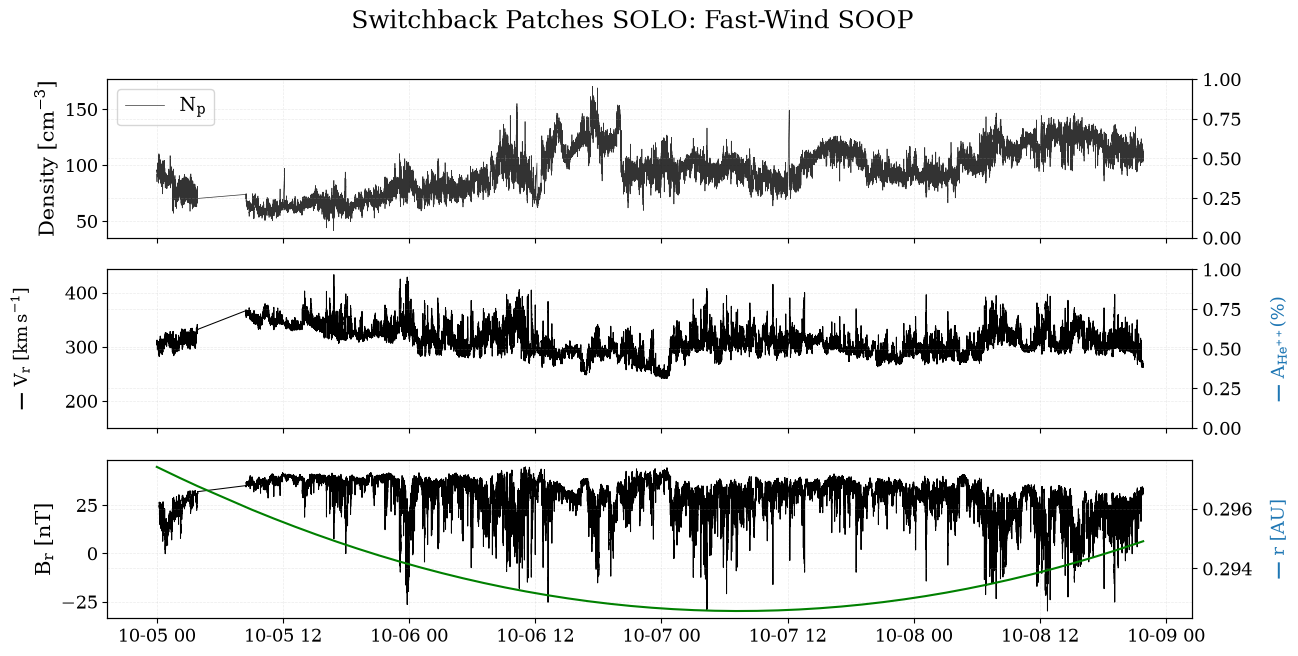

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches SOLO: Fast-Wind SOOP")

plt.rcParams["mathtext.default"] = "regular"

time_index = data_solo.index

ax1b = ax1.twinx()
ax1.plot(time_index, data_solo['Np'], label='$N_p$', color='black', linewidth='0.5', alpha=0.8)
# ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
# ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

ax2b = ax2.twinx()
ax2.plot(time_index, data_solo['Vp_r'], label='$V_p$', color='black', linewidth='0.75')
# ax2b.plot(time_index,alpha_abundance_PSP_average,label=r'$\alpha _{\%}$',color='tab:blue',linewidth=0.75,alpha=0.8)
# ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')
ax2.set_ylim(150, None)

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b = ax3.twinx()
ax3.plot(time_index, data_solo['Br'], color ='black', linewidth='0.75')
ax3b.plot(time_index, data_solo['r_sun'], color='green')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
# ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [14]:
""" Ephemeris Data """
phi, theta, solo_r_sun = data_solo['car_lon'], data_solo['car_lat'], data_solo['r_sun']

In [16]:
phi

2023-10-05 00:00:01.576999936   -175.845574
2023-10-05 00:01:17.576999936   -175.851501
2023-10-05 00:01:21.576999936   -175.851813
2023-10-05 00:01:25.576999936   -175.852125
2023-10-05 00:01:29.576999936   -175.852437
                                    ...    
2023-10-08 21:48:54.204000000    158.383271
2023-10-08 21:48:58.204000000    158.382962
2023-10-08 21:49:02.204000000    158.382653
2023-10-08 21:49:06.204000000    158.382344
2023-10-08 21:49:10.204000000    158.382036
Name: car_lon, Length: 77215, dtype: float64

In [19]:
t_coord = time_index

phi_rad   = phi * np.pi/180
theta_rad = theta * np.pi/180

phi_rad_new   = phi_rad#['lon iau_sun']
theta_rad_new = theta_rad#['lat iau_sun']

t_coord_float = t_coord.astype(np.int64) / 1e9
df_time_float = data_solo['Vp_r'].index.astype(np.int64) / 1e9

interp_theta = interp1d(t_coord_float, theta_rad_new, kind='linear', bounds_error=False, fill_value="extrapolate")
interp_phi   = interp1d(t_coord_float, phi_rad_new,   kind='linear', bounds_error=False, fill_value="extrapolate")

theta_z = interp_theta(df_time_float)
phi_z   = interp_phi(df_time_float)

dtheta = np.diff(theta_z)
dphi   = np.diff(phi_z)

ds_solo    = np.sqrt(dtheta**2 + (np.cos(theta_z[:-1]) * dphi)**2)
s_solo     = np.concatenate([[0], np.cumsum(ds_solo)])
s_solo_deg = np.degrees(s_solo)

(150.0, 442.70322341918944)

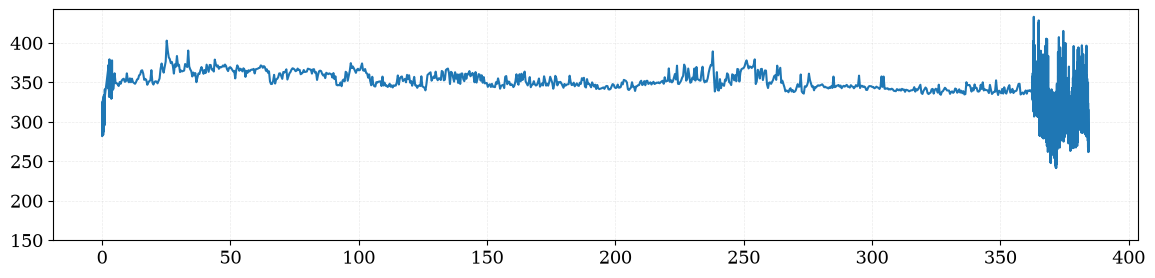

In [21]:
plt.figure(figsize=(14,3))
plt.plot(s_solo_deg, data_solo['Vp_r'])
plt.ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

In [24]:
f_cut = 9e-1

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Normalised Deflection

In [27]:
""" Compute Normalised Deflection """

' Compute Normalised Deflection '

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

In [32]:
data_solo['Vp_r'] = data_solo['Vp_r'].fillna(data_solo['Vp_r'].mean())

# --- Regular sampling ---
s_solo_new = np.linspace(0, max(s_solo_deg), int(max(s_solo_deg)/min(np.diff(s_solo_deg))))

v_r_interp = interp1d(s_solo_deg, data_solo['Vp_r'], kind='linear', bounds_error=False, fill_value="extrapolate")
v_r_new = v_r_interp(s_solo_new)

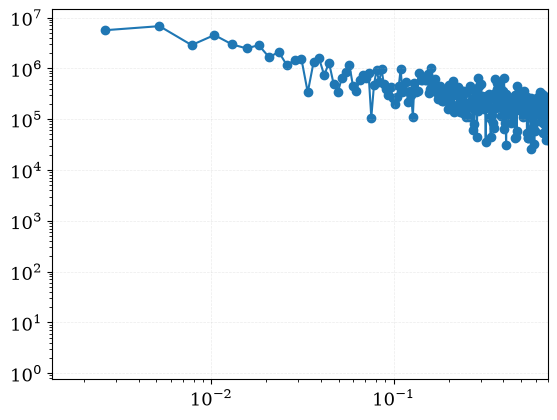

In [34]:
# --- velocity
ds_vr = np.mean(np.diff(s_solo_new))

fft_vr  = np.fft.rfft(v_r_new)
freq_vr = np.fft.rfftfreq(len(v_r_new), d=ds_vr)

plt.loglog(freq_vr[1:], np.abs(fft_vr[1:]))
plt.scatter(freq_vr[1:], np.abs(fft_vr[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 7e-1)
plt.show()

In [36]:
idx_cut_vr = np.argmin(np.abs(freq_vr - f_cut))

fft_vr[idx_cut_vr:] = 0.0

(150.0, 437.8437469123951)

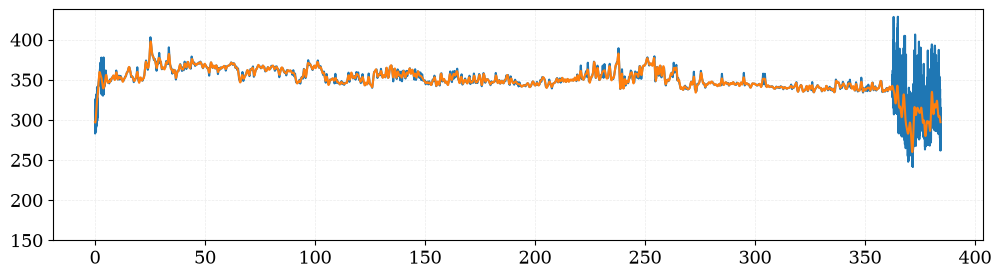

In [38]:
filter_data_vr = np.fft.irfft(fft_vr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, v_r_new)
ax.plot(s_solo_new[:-1], filter_data_vr)
ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

In [41]:
velocirap = False

if velocirap:
    data = _read_velocirap_file(start_SOLO, stop_SOLO)
    data_res = resample_dataframe(data, data_solo.index)
else:
    l3_path = spz.inventories.data_tree.amda.DerivedParameters
    Na = spz.get_data(l3_path.pas_na_nomag, start_SOLO, stop_SOLO).to_dataframe()
    Np = spz.get_data(l3_path.pas_np_nomag, start_SOLO, stop_SOLO).to_dataframe()
    data = pd.concat([Np, Na],axis=1)
    data_res = resample_dataframe(data, data_solo.index)
    
data_res

,PAS Proton Density,PAS alpha density
2023-10-05 00:00:01.576999936,NaN,NaN
2023-10-05 00:01:17.576999936,NaN,NaN
2023-10-05 00:01:21.576999936,76.074799,NaN
2023-10-05 00:01:25.576999936,78.573441,NaN
2023-10-05 00:01:29.576999936,81.072090,NaN
...,...,...
2023-10-08 21:48:54.204000000,88.608963,8.525383
2023-10-08 21:48:58.204000000,87.696754,8.525383
2023-10-08 21:49:02.204000000,83.952354,8.525383
2023-10-08 21:49:06.204000000,84.620689,8.525383


In [42]:
if velocirap:
    alpha_abundance_SOLO = (data_res['Na'] / (data_res['Na'] + data_res['Np'])) * 100
    alpha_percent = pd.DataFrame(alpha_abundance_SOLO)
    alpha_percent.columns = ["a_percent"]   
else:
    alpha_abundance_SOLO = (data_res['PAS alpha density'] / (data_res['PAS alpha density'] + data_res['PAS Proton Density'])) * 100
    alpha_percent = pd.DataFrame(alpha_abundance_SOLO)
    alpha_percent.columns = ["a_percent"]   

In [43]:
alpha_percent.loc[np.isnan(alpha_percent['a_percent']), "a_percent"] = np.mean(alpha_percent['a_percent'])

# --- Regular sampling ---
a_percent_interp = interp1d(s_solo_deg, alpha_percent['a_percent'], kind='linear', bounds_error=False, fill_value="extrapolate")
a_percent_new = a_percent_interp(s_solo_new)

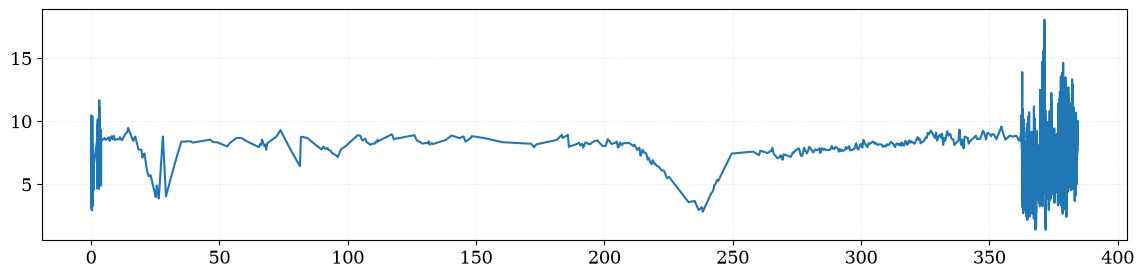

In [44]:
plt.figure(figsize=(14, 3))
plt.plot(s_solo_new, a_percent_new)

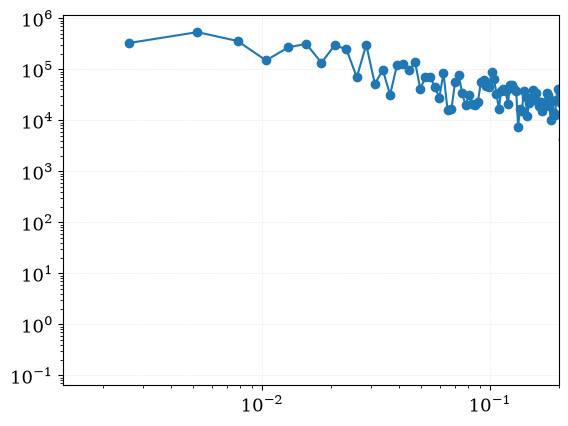

In [45]:
# --- alpha abundance
ds_a_percent = np.mean(np.diff(s_solo_new))

fft_a_percent  = np.fft.rfft(a_percent_new)
freq_a_percent = np.fft.rfftfreq(len(a_percent_new), d=ds_a_percent)

plt.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 2e-1)
plt.show()

In [46]:
idx_cut_a_percent = np.argmin(np.abs(freq_a_percent - f_cut))

fft_a_percent[idx_cut_a_percent:] = 0.0

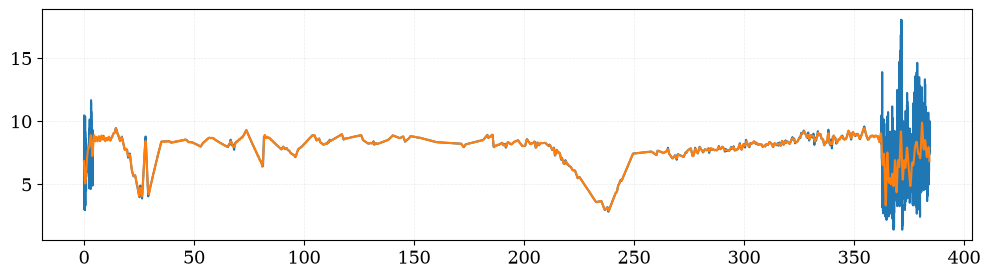

In [48]:
filter_data_a_percent = np.fft.irfft(fft_a_percent)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, a_percent_new)
ax.plot(s_solo_new[:-1], filter_data_a_percent)
#ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>

In [50]:
r_a_vr, p_a_vr = stats.pearsonr(filter_data_vr, filter_data_a_percent)
r_a_vr

np.float64(-0.02568590761503687)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Figures
</p>

</div>

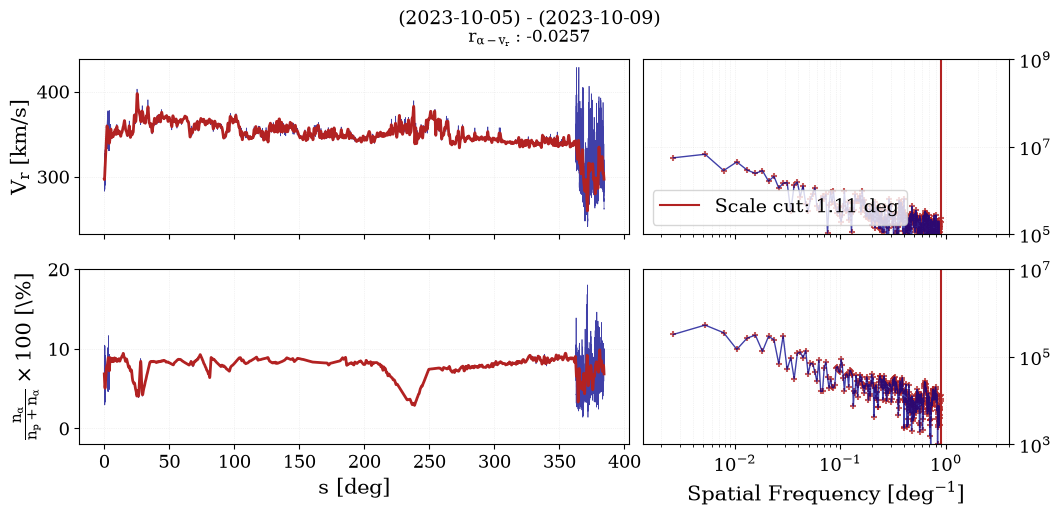

In [52]:
fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], wspace=0.03, hspace=0.2)

fig.suptitle(
    rf"({start_SOLO.strftime('%Y-%m-%d')}) - ({stop_SOLO.strftime('%Y-%m-%d')})",
    fontsize=14
)

fig.text(
    0.5, 0.94,
    rf"$r_{{\alpha-v_r}}$ : {r_a_vr:.4f}",
    ha="center",
    va="top",
    fontsize=12
)

# Left column: time series
ax_v = fig.add_subplot(gs[0, 0])
ax_a = fig.add_subplot(gs[1, 0], sharex=ax_v)

# Right column: spectra
ax_v_spec = fig.add_subplot(gs[0, 1])
ax_a_spec = fig.add_subplot(gs[1, 1])#, sharex=ax_v_spec)

# Velocity time series
ax_v.plot(s_solo_new, v_r_new, color = 'darkblue', linewidth=0.5, alpha=0.75)
ax_v.plot(s_solo_new[:-1], filter_data_vr, linewidth=2.0, color='firebrick')
ax_v.set_ylabel(r"$V_r$ [$km/s$]")
ax_v.tick_params(labelbottom=False)
ax_v.grid(which="both", linestyle=":", alpha=0.3)

# Velocity spectrum
ax_v_spec.loglog(freq_vr[1:], np.abs(fft_vr[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_v_spec.scatter(freq_vr[1:], np.abs(fft_vr[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_v_spec.axvline(freq_vr[idx_cut_vr], color="firebrick", linestyle="-", linewidth=1.5, label=f"Scale cut: {round(1/f_cut, 2)} deg")
ax_v_spec.set_xlim(None, 4e0)
ax_v_spec.set_ylim(1e5, 1e9)
ax_v_spec.grid(which="both", linestyle=":", alpha=0.3)
ax_v_spec.tick_params(labelbottom=False)
ax_v_spec.legend(loc="lower left")

# Alpha abundance time series
ax_a.plot(s_solo_new, a_percent_new, linewidth=0.5, color='darkblue', alpha=0.75)
ax_a.plot(s_solo_new[:-1], filter_data_a_percent, color="firebrick", linewidth=2.0)
ax_a.set_ylabel(r"$\frac{n_\alpha}{n_p+n_\alpha}\times100$ [\%]")
ax_a.set_xlabel("s [deg]")
ax_a.set_ylim(-2, 20)
ax_a.grid(which="both", linestyle=":", alpha=0.3)

# Alpha spectrum
ax_a_spec.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_a_spec.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_a_spec.axvline(freq_a_percent[idx_cut_a_percent], color="firebrick", linestyle="-", linewidth=1.5)
ax_a_spec.set_xlabel("Spatial Frequency [$deg^{-1}$]")
ax_a_spec.set_xlim(None, 4e0)
ax_a_spec.set_ylim(1e3, 1e7)
ax_a_spec.grid( which="both", linestyle=":", alpha=0.3)

ax_v_spec.yaxis.tick_right()
ax_v_spec.yaxis.set_label_position("right")

ax_a_spec.yaxis.tick_right()
ax_a_spec.yaxis.set_label_position("right")

# Save
#fig.savefig(
#    Path("..") / "Results" / "Figures" /
#    f"SOLO-corr_{start_SOLO.strftime('%Y-%m-%d')}_"
#    f"{stop_SOLO.strftime('%Y-%m-%d')}_"
#    f"{round(1/f_cut, 2)}.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()